# Object Detection Training (Performance-Focused)

This notebook keeps the same `Images/` and `label/` dataset layout used in this repo, but replaces the Python generator with a `tf.data` input pipeline optimized for throughput.

In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

keras.utils.set_random_seed(42)
print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.10.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:

USE_MIXED_PRECISION = True

ENABLE_XLA = os.name != 'nt'
BATCH_SIZE = 128
EPOCHS = 40
IMAGE_SIZE = (128, 128)
CACHE_TO_DISK = False
CACHE_DIR = Path('cache')

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as exc:
        print('Could not enable memory growth:', exc)

if ENABLE_XLA:
    tf.config.optimizer.set_jit(True)

if USE_MIXED_PRECISION and gpus:
    keras.mixed_precision.set_global_policy('mixed_float16')
else:
    keras.mixed_precision.set_global_policy('float32')

print('Mixed precision policy:', keras.mixed_precision.global_policy())
print('XLA enabled:', ENABLE_XLA)

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5070 Ti, compute capability 12.0
Mixed precision policy: <Policy "mixed_float16">
XLA enabled: False


In [3]:
ROOT = Path('.')
IMAGES_DIR = ROOT / 'Images'
LABELS_DIR = ROOT / 'label'

assert IMAGES_DIR.exists(), f'Missing directory: {IMAGES_DIR}'
assert LABELS_DIR.exists(), f'Missing directory: {LABELS_DIR}'

image_paths = sorted(IMAGES_DIR.glob('*.png'))
label_paths = sorted(LABELS_DIR.glob('*.txt'))

assert image_paths, 'No PNG files found in Images/'
assert len(image_paths) == len(label_paths), 'Image/label count mismatch'

paired_paths = []
for image_path in image_paths:
    label_path = LABELS_DIR / f'{image_path.stem}.txt'
    if not label_path.exists():
        raise FileNotFoundError(f'Missing label for {image_path.name}')
    paired_paths.append((str(image_path), str(label_path)))

train_pairs, val_pairs = train_test_split(
    paired_paths,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

print(f'Total samples: {len(paired_paths)}')
print(f'Train samples: {len(train_pairs)}')
print(f'Val samples:   {len(val_pairs)}')

Total samples: 42000
Train samples: 33600
Val samples:   8400


In [4]:
AUTOTUNE = tf.data.AUTOTUNE
COORD_SCALE = tf.constant([IMAGE_SIZE[1], IMAGE_SIZE[0], IMAGE_SIZE[1], IMAGE_SIZE[0]], dtype=tf.float32)

def decode_image(image_path):
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_png(image_bytes, channels=1)
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    image = tf.cast(image, tf.float32) / 255.0
    return image

def decode_label(label_path):
    label_text = tf.io.read_file(label_path)
    parts = tf.strings.split(tf.strings.strip(label_text))
    bbox = tf.strings.to_number(parts, out_type=tf.float32)
    bbox = bbox / COORD_SCALE
    return bbox

def load_example(image_path, label_path):
    image = decode_image(image_path)
    bbox = decode_label(label_path)
    return image, bbox

def build_dataset(pairs, training):
    image_files = [pair[0] for pair in pairs]
    label_files = [pair[1] for pair in pairs]

    ds = tf.data.Dataset.from_tensor_slices((image_files, label_files))

    options = tf.data.Options()
    options.experimental_deterministic = not training
    ds = ds.with_options(options)

    if training:
        ds = ds.shuffle(len(pairs), reshuffle_each_iteration=True)

    ds = ds.map(load_example, num_parallel_calls=AUTOTUNE)

    if CACHE_TO_DISK:
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        cache_name = 'train' if training else 'val'
        ds = ds.cache(str(CACHE_DIR / cache_name))

    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_pairs, training=True)
val_ds = build_dataset(val_pairs, training=False)

In [5]:
def benchmark_dataset(dataset, steps=100):
    start = time.perf_counter()
    batch_count = 0
    sample_count = 0
    for images, labels in dataset.take(steps):
        batch_count += 1
        sample_count += int(images.shape[0])
        _ = labels
    duration = time.perf_counter() - start
    print(f'Batches: {batch_count}')
    print(f'Samples: {sample_count}')
    print(f'Time: {duration:.2f}s')
    print(f'Throughput: {sample_count / max(duration, 1e-6):.2f} samples/s')

benchmark_dataset(train_ds, steps=min(100, max(1, len(train_pairs) // BATCH_SIZE)))

Batches: 100
Samples: 12800
Time: 2.04s
Throughput: 6280.12 samples/s


In [6]:
def conv_block(x, filters, pool=True):
    x = layers.SeparableConv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SeparableConv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    if pool:
        x = layers.MaxPooling2D(pool_size=2)(x)
    return x

def build_bbox_model():
    inputs = keras.Input(shape=(*IMAGE_SIZE, 1))

    x = conv_block(inputs, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 192, pool=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(4, activation='sigmoid', dtype='float32', name='bbox')(x)
    return keras.Model(inputs=inputs, outputs=outputs)

model = build_bbox_model()
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 1)]     0         
                                                                 
 separable_conv2d (Separable  (None, 128, 128, 32)     41        
 Conv2D)                                                         
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 32)     128       
 ormalization)                                                   
                                                                 
 re_lu (ReLU)                (None, 128, 128, 32)      0         
                                                                 
 separable_conv2d_1 (Separab  (None, 128, 128, 32)     1312      
 leConv2D)                                                       
                                                             

In [ ]:
def bbox_iou(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    true_x1 = tf.minimum(y_true[..., 0], y_true[..., 2])
    true_y1 = tf.minimum(y_true[..., 1], y_true[..., 3])
    true_x2 = tf.maximum(y_true[..., 0], y_true[..., 2])
    true_y2 = tf.maximum(y_true[..., 1], y_true[..., 3])

    pred_x1 = tf.minimum(y_pred[..., 0], y_pred[..., 2])
    pred_y1 = tf.minimum(y_pred[..., 1], y_pred[..., 3])
    pred_x2 = tf.maximum(y_pred[..., 0], y_pred[..., 2])
    pred_y2 = tf.maximum(y_pred[..., 1], y_pred[..., 3])

    inter_x1 = tf.maximum(true_x1, pred_x1)
    inter_y1 = tf.maximum(true_y1, pred_y1)
    inter_x2 = tf.minimum(true_x2, pred_x2)
    inter_y2 = tf.minimum(true_y2, pred_y2)

    inter_w = tf.maximum(inter_x2 - inter_x1, 0.0)
    inter_h = tf.maximum(inter_y2 - inter_y1, 0.0)
    inter_area = inter_w * inter_h

    true_area = tf.maximum(true_x2 - true_x1, 0.0) * tf.maximum(true_y2 - true_y1, 0.0)
    pred_area = tf.maximum(pred_x2 - pred_x1, 0.0) * tf.maximum(pred_y2 - pred_y1, 0.0)
    union_area = tf.maximum(true_area + pred_area - inter_area, keras.backend.epsilon())

    return inter_area / union_area

class BBoxIoU(keras.metrics.MeanMetricWrapper):
    def __init__(self, name='iou', **kwargs):
        super().__init__(bbox_iou, name=name, **kwargs)

In [7]:
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.Huber(),
    metrics=[keras.metrics.MeanAbsoluteError(name='mae'), BBoxIoU(name='iou')],
    jit_compile=ENABLE_XLA,
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, min_delta=1e-4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('Models/bbox_model_performance.keras', monitor='val_loss', save_best_only=True),
]

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

model.save('Models/bbox_model_performance_last.keras')

Epoch 1/40
263/263 [==============================] - 450s 652ms/step - loss: 0.0041 - mae: 0.0603 - val_loss: 0.0305 - val_mae: 0.2092 - lr: 0.0010
Epoch 2/40
263/263 [==============================] - 170s 644ms/step - loss: 6.8468e-04 - mae: 0.0289 - val_loss: 0.0157 - val_mae: 0.1498 - lr: 0.0010
Epoch 3/40
263/263 [==============================] - 170s 645ms/step - loss: 5.5652e-04 - mae: 0.0262 - val_loss: 2.6354e-04 - val_mae: 0.0188 - lr: 0.0010
Epoch 4/40
263/263 [==============================] - 173s 659ms/step - loss: 5.1052e-04 - mae: 0.0251 - val_loss: 1.6995e-04 - val_mae: 0.0152 - lr: 0.0010
Epoch 5/40
263/263 [==============================] - 178s 676ms/step - loss: 4.4952e-04 - mae: 0.0235 - val_loss: 1.2850e-04 - val_mae: 0.0130 - lr: 0.0010
Epoch 6/40
263/263 [==============================] - 177s 673ms/step - loss: 4.2240e-04 - mae: 0.0228 - val_loss: 3.0957e-04 - val_mae: 0.0194 - lr: 0.0010
Epoch 7/40
263/263 [==============================] - 174s 663ms/step 

In [11]:
model.save('bbox_model.h5')
model.save('bbox_model.keras')

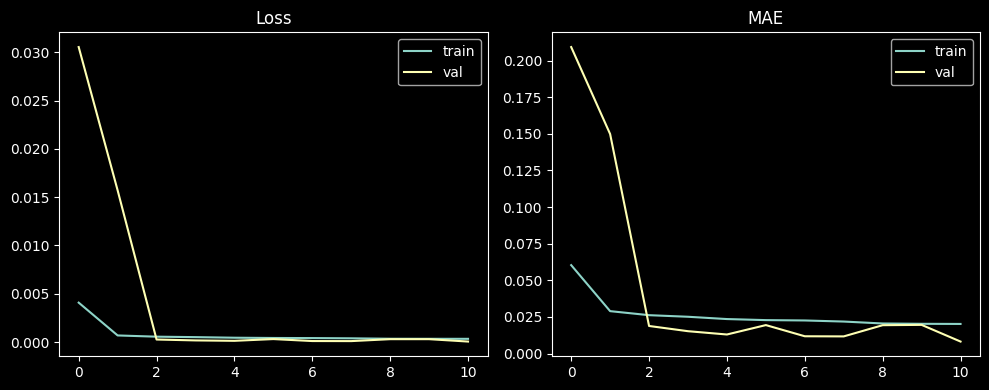

In [9]:
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.title('MAE')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['iou'], label='train')
plt.plot(history.history['val_iou'], label='val')
plt.title('IoU')
plt.legend()
plt.tight_layout()
plt.show()

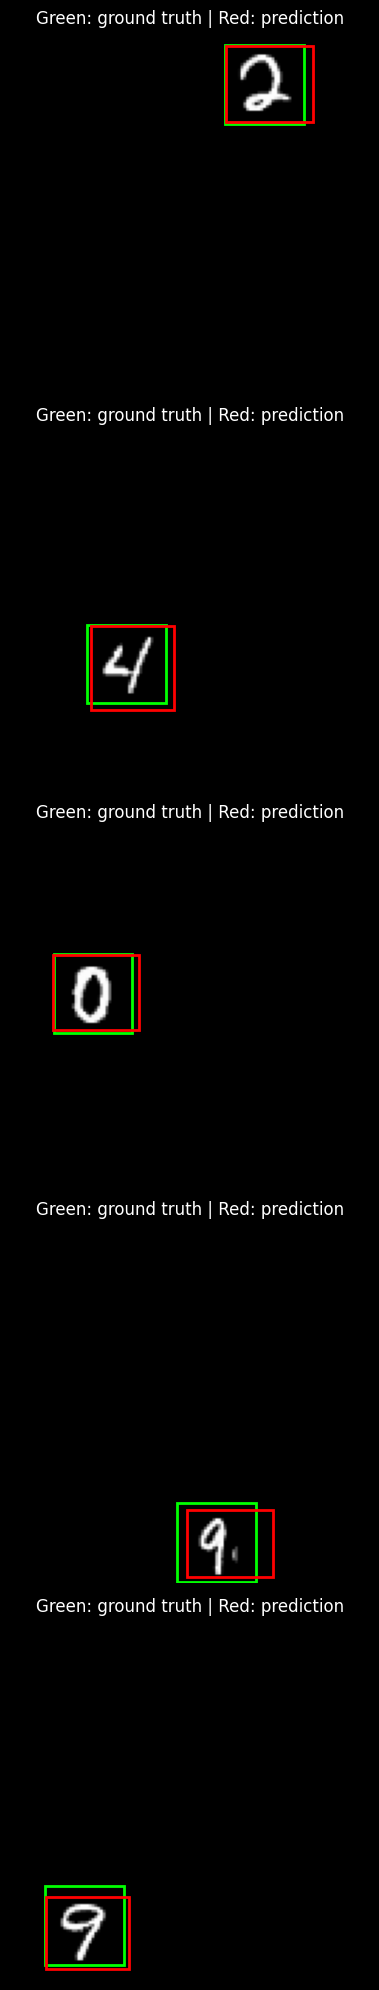

In [13]:
def denormalize_bbox(bbox):
    return bbox * COORD_SCALE.numpy()

def show_predictions(dataset, rows=5):
    images, labels = next(iter(dataset.take(1)))
    preds = model.predict(images, verbose=0)

    plt.figure(figsize=(12, 4 * rows))
    for idx in range(min(rows, images.shape[0])):
        image = images[idx].numpy().squeeze()
        true_bbox = denormalize_bbox(labels[idx].numpy())
        pred_bbox = denormalize_bbox(preds[idx])

        ax = plt.subplot(rows, 1, idx + 1)
        ax.imshow(image, cmap='gray')

        tx1, ty1, tx2, ty2 = true_bbox
        px1, py1, px2, py2 = pred_bbox

        ax.add_patch(plt.Rectangle((tx1, ty1), tx2 - tx1, ty2 - ty1, fill=False, color='lime', linewidth=2))
        ax.add_patch(plt.Rectangle((px1, py1), px2 - px1, py2 - py1, fill=False, color='red', linewidth=2))
        ax.set_title('Green: ground truth | Red: prediction')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(val_ds)